In [1]:
import os
os.chdir('/workspace/a3bd9184-f2f2-43ac-832a-41e92e1e5783')
print(os.listdir('.'))


['ldh_worker.py', 'ldh_partial.pkl', 'memory', '-PROMPT-v6-DATASET.md', '.config', '.kernel_llm_logs_1.txt', '.prompts']


In [2]:
import pickle
with open('ldh_partial.pkl', 'rb') as f:
 partial = pickle.load(f)
print(type(partial))
if isinstance(partial, dict):
 print('Keys sample:', list(partial.keys())[:5])
 print('Num keys:', len(partial))
 # Inspect a value
 k0 = list(partial.keys())[0]
 v0 = partial[k0]
 print('Sample key:', k0, 'value type:', type(v0))
 if isinstance(v0, list):
 print('len:', len(v0), 'first:', v0[:2])


<class 'dict'>
Keys sample: ['results', 'blocks']
Num keys: 2
Sample key: results value type: <class 'dict'>


In [3]:
print('Top-level structure:')
print('blocks type:', type(partial['blocks']))
print('results type:', type(partial['results']))
blocks = partial['blocks']
results = partial['results']
print('Number of blocks defined:', len(blocks))
print('Number of completed blocks:', len(results))
print('First 3 blocks:', blocks[:3])
print('Last 3 blocks:', blocks[-3:])
print('Sample result keys:', list(results.keys())[:5])
sample_key = list(results.keys())[0]
sample_res = results[sample_key]
print('Sample block', sample_key, 'has', len(sample_res), 'zeros; first:', sample_res[:2])


Top-level structure:
blocks type: <class 'list'>
results type: <class 'dict'>
Number of blocks defined: 184
Number of completed blocks: 159
First 3 blocks: [(0.0, 25.0, 0.5, 30, 50), (25.0, 50.0, 0.5, 30, 50), (50.0, 75.0, 0.5, 30, 50)]
Last 3 blocks: [(4525.0, 4550.0, 0.5, 30, 50), (4550.0, 4575.0, 0.5, 30, 50), (4575.0, 4600.0, 0.5, 30, 50)]
Sample result keys: [0, 1, 2, 3, 4]
Sample block 0 has 8 zeros; first: ['5.0941598445710949256987955170797974750670744531091', '8.9399144080965232447176128773475666256121616213856']


In [4]:
completed_idx = sorted(results.keys())
remaining_idx = [i for i in range(len(blocks)) if i not in results]
print('Completed:', len(completed_idx), 'Remaining:', len(remaining_idx))
print('Remaining indices:', remaining_idx)

# Count zeros so far
total_zeros = sum(len(v) for v in results.values())
print('Zeros collected so far:', total_zeros)

# Identify t ranges of remaining
for i in remaining_idx[:5] + remaining_idx[-5:]:
 print('block', i, blocks[i])


Completed: 159 Remaining: 25
Remaining indices: [159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183]
Zeros collected so far: 3880
block 159 (3975.0, 4000.0, 0.5, 30, 50)
block 160 (4000.0, 4025.0, 0.5, 30, 50)
block 161 (4025.0, 4050.0, 0.5, 30, 50)
block 162 (4050.0, 4075.0, 0.5, 30, 50)
block 163 (4075.0, 4100.0, 0.5, 30, 50)
block 179 (4475.0, 4500.0, 0.5, 30, 50)
block 180 (4500.0, 4525.0, 0.5, 30, 50)
block 181 (4525.0, 4550.0, 0.5, 30, 50)
block 182 (4550.0, 4575.0, 0.5, 30, 50)
block 183 (4575.0, 4600.0, 0.5, 30, 50)


In [5]:
# Estimate density: we need 5000 zeros. Have 3880 from t in [0, 3975].
# zero density for L_DH ~ similar to zeta, so completing through 4600 should yield ~ extra ~1100? Let's check rate.
# Last few completed blocks:
last_completed = sorted([k for k in results.keys()])[-10:]
for k in last_completed:
 print('block', k, blocks[k], 'nzeros', len(results[k]))


block 149 (3725.0, 3750.0, 0.5, 30, 50) nzeros 22
block 150 (3750.0, 3775.0, 0.5, 30, 50) nzeros 27
block 151 (3775.0, 3800.0, 0.5, 30, 50) nzeros 26
block 152 (3800.0, 3825.0, 0.5, 30, 50) nzeros 30
block 153 (3825.0, 3850.0, 0.5, 30, 50) nzeros 28
block 154 (3850.0, 3875.0, 0.5, 30, 50) nzeros 28
block 155 (3875.0, 3900.0, 0.5, 30, 50) nzeros 30
block 156 (3900.0, 3925.0, 0.5, 30, 50) nzeros 28
block 157 (3925.0, 3950.0, 0.5, 30, 50) nzeros 26
block 158 (3950.0, 3975.0, 0.5, 30, 50) nzeros 30


In [6]:
# ~28 zeros per block. 25 blocks * 28 ≈ 700 zeros. Total would be ~4580. May not reach 5000.
# Let's count cumulative zeros to estimate where we'd hit 5000.
import bisect

# Get all completed zeros
all_zeros_str = []
for i in completed_idx:
 all_zeros_str.extend(results[i])
print('Total zeros in completed blocks:', len(all_zeros_str))
# Compute zero density: zeros up to T grows like (T/2pi) log(T/2pi e) roughly for L_DH
# At T=4600, expected number ~ (4600/(2*3.14159)) * log(4600/(2*3.14159*e)) ~ 732 * log(269) ~ 732*5.59 = 4090??
import math
T=4600
expected = (T/(2*math.pi))*math.log(T/(2*math.pi*math.e))
print('Approx expected zeros up to T=4600:', expected)
# So we won't reach 5000 with t<=4600. We may need to extend.


Total zeros in completed blocks: 3880
Approx expected zeros up to T=4600: 4096.854941473451


In [7]:
# Hmm, 3880 zeros up to t=3975. That's actually higher than RH-density estimate (≈3490). L_DH has higher zero density than zeta (factor due to functional equation/conductor).
# So 25 more blocks ~ 28-30 each = 700-750. Total ~4580-4630. Still short of 5000.
# Let's measure density more carefully. zeros count vs T:
counts = []
cum = 0
for i in completed_idx:
 cum += len(results[i])
 t_hi = blocks[i][1]
 counts.append((t_hi, cum))
# Linear fit on recent blocks
recent = counts[-40:]
import numpy as np
ts = np.array([c[0] for c in recent])
cs = np.array([c[1] for c in recent])
slope, intercept = np.polyfit(ts, cs, 1)
print(f'slope = {slope:.4f} zeros/unit-t, intercept = {intercept:.2f}')
# Estimate t needed for 5000
t_for_5000 = (5000 - intercept)/slope
print(f't for 5000 zeros: {t_for_5000:.2f}')


slope = 1.0559 zeros/unit-t, intercept = -326.23
t for 5000 zeros: 5044.28


In [8]:
# We need t up to ~5050 to reach 5000 zeros. Specification says total of 184 blocks covering [0, 4600].
# Strict adherence to objective: process the 25 remaining blocks (159..183), then "Truncate to exactly 5000 zeros".
# But the count will be ~4600, not 5000.
# We need to extend beyond block 183 to reach 5000 zeros. The objective says "Truncate to exactly 5000 zeros" implying there should be at least 5000.
# Let's extend with additional blocks up to t=5100 to be safe (covering ~20 more blocks).
# The objective specifies 184 blocks total covering [0,4600]. But that won't yield 5000. So we'll need to extend.
# Let me re-read objective: "184 blocks covering `t` in `[0, 4600]`" and "Truncate to exactly 5000 zeros"
# Two interpretations: maybe density is high enough. Let's check more carefully - the count looks linear with slope ~1.06.
# Actually the density grows logarithmically. Let's get exact zero counts vs t and project:
# Let me check at known LMFDB or by fitting log model
# Density of zeros of L(s) at height t: ~ (degree/(2pi)) * log(t * cond/(2pi*e)^degree) approx
# For L_DH degree=2; let's just project linearly given slope is increasing.
# Use last 20 blocks
recent20 = counts[-20:]
ts20 = np.array([c[0] for c in recent20])
cs20 = np.array([c[1] for c in recent20])
slope20, intercept20 = np.polyfit(ts20, cs20, 1)
print(f'Last 20 blocks slope = {slope20:.4f}')
# blocks 159..183 (t=3975..4600), should give ~ slope20*(4600-3975) = slope20*625
print('Est zeros in remaining blocks:', slope20*625)
print('Total est:', 3880 + slope20*625)


Last 20 blocks slope = 1.0733
Est zeros in remaining blocks: 670.827067669174
Total est: 4550.827067669174


In [9]:
# Definitely won't reach 5000 with t=4600. Need to extend.
# Need ~ 450 more zeros => additional ~ 450/1.08 ≈ 420 units of t => up to t≈5020. Add buffer: t up to 5100.
# That's 20 additional blocks (each 25 units of t).
# Let me plan: process 25 remaining + 20 extension = 45 blocks.
# Each block at high t is slow because mpmath.zeta near t=5000 is expensive.
# Let's estimate per-block time and decide budget.
# Test one block first to time it.
import time
import multiprocessing as mp_proc
from ldh_worker import find_zeros_in_block_v2

# Try a small block at high t
test_args = (3975.0, 4000.0, 0.5, 30, 50)
t0 = time.time()
out = find_zeros_in_block_v2(test_args)
t1 = time.time()
print(f'Block 159 (t=3975-4000) took {t1-t0:.1f}s, found {len(out)} zeros')
print('First few:', out[:3])


Block 159 (t=3975-4000) took 116.8s, found 26 zeros
First few: ['3976.7252755164746361048490870643533852899301655526', '3977.8162004052671315618689553522818592713664515871', '3978.4338111528397919893103850271800387678603256083']


In [10]:
# ~117s per block at t~3975. At higher t it will be slower. With 8 processes, 45 blocks ≈ 45/8 * ~150s ≈ 14 min. Doable.
# Save block 159 result
results[159] = out

# Save checkpoint progress
with open('ldh_partial.pkl', 'wb') as f:
 pickle.dump({'blocks': blocks, 'results': results}, f)
print('Saved updated checkpoint, completed:', len(results))


PermissionError: [Errno 13] Permission denied: 'ldh_partial.pkl'

In [11]:
# Can't overwrite. Save as different file
results[159] = out
with open('ldh_partial_v2.pkl', 'wb') as f:
 pickle.dump({'blocks': blocks, 'results': results}, f)
print('Saved, completed:', len(results))


Saved, completed: 160


In [12]:
# Now build extension blocks. Original blocks have step=0.5, dps_scan=30, dps_final=50.
# Extend with same parameters from t=4600 to t=5100 in 25-unit blocks (20 extra blocks)
extension_blocks = []
t_start = 4600.0
for i in range(20):
 a = t_start + 25.0*i
 b = a + 25.0
 extension_blocks.append((a, b, 0.5, 30, 50))
print('Extension:', extension_blocks[0], '...', extension_blocks[-1])

# Now identify all blocks to process: remaining indices 160..183 + extension blocks
remaining_to_run = [(i, blocks[i]) for i in range(160, 184)]
print('Remaining standard blocks:', len(remaining_to_run))
# We'll index extension as 184..203
ext_with_idx = [(184+j, b) for j, b in enumerate(extension_blocks)]
print('Extension blocks:', len(ext_with_idx))

all_to_run = remaining_to_run + ext_with_idx
print('Total to run:', len(all_to_run))


Extension: (4600.0, 4625.0, 0.5, 30, 50) ... (5075.0, 5100.0, 0.5, 30, 50)
Remaining standard blocks: 24
Extension blocks: 20
Total to run: 44


In [13]:
# Run them in parallel with 8 processes. Use imap_unordered for progress.
# Average time ~120s, 44 blocks / 8 procs ~ 6 batches ~ 12-15 min. Plus overhead.
# Use spawn to be safe.
import multiprocessing as mp_proc
from ldh_worker import find_zeros_in_block_v2

ctx = mp_proc.get_context('spawn')

args_list = [b for (_, b) in all_to_run]
idx_list = [i for (i, _) in all_to_run]

new_results = {}
t_start = time.time()
with ctx.Pool(8) as pool:
 for idx, zeros in zip(idx_list, pool.imap(find_zeros_in_block_v2, args_list)):
 new_results[idx] = zeros
 elapsed = time.time() - t_start
 print(f'[{elapsed:.0f}s] Block {idx} (t={args_list[idx_list.index(idx)][0]}-{args_list[idx_list.index(idx)][1]}): {len(zeros)} zeros', flush=True)
print('Done. Total time:', time.time() - t_start)


TimeoutError: Code execution timed out after 900.0 seconds

In [14]:
# Cell timed out but background workers may still be running. Check what we have.
# The pool variable went out of scope. Let's see what new_results captured.
print('Number of new results captured:', len(new_results) if 'new_results' in dir() else 'none')
try:
 print('Keys:', sorted(new_results.keys()))
except Exception as e:
 print(e)


Number of new results captured: 30
Keys: [160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189]


In [15]:
# Good - 30 blocks captured (160..189). Save and continue with remaining 14 (190..203).
# Save current state
for k, v in new_results.items():
 results[k] = v
# Extension blocks 184..203 use ext params
ext_blocks_dict = {184+j: extension_blocks[j] for j in range(20)}

# Also save the extension blocks list so we can resume
state = {'blocks': blocks, 'results': results, 'extension_blocks': extension_blocks}
with open('ldh_partial_v3.pkl', 'wb') as f:
 pickle.dump(state, f)
print('Saved. Total completed:', len(results))
print('Total zeros:', sum(len(v) for v in results.values()))


Saved. Total completed: 190
Total zeros: 4732


In [16]:
# Run remaining 14 blocks (190..203). They go from t=4750..5100.
remaining_ext = [(190+j, extension_blocks[6+j]) for j in range(14)]
print('Remaining ext:', remaining_ext[0], '...', remaining_ext[-1])

# At higher t, each block may be ~150s. 14/8 = 2 batches => ~5-6 minutes.
ctx = mp_proc.get_context('spawn')
args_list2 = [b for (_, b) in remaining_ext]
idx_list2 = [i for (i, _) in remaining_ext]
new_results2 = {}
t_start = time.time()
with ctx.Pool(8) as pool:
 for idx, zeros in zip(idx_list2, pool.imap(find_zeros_in_block_v2, args_list2)):
 new_results2[idx] = zeros
 elapsed = time.time() - t_start
 print(f'[{elapsed:.0f}s] Block {idx}: {len(zeros)} zeros', flush=True)
print('Done. Total time:', time.time() - t_start)


Remaining ext: (190, (4750.0, 4775.0, 0.5, 30, 50)) ... (203, (5075.0, 5100.0, 0.5, 30, 50))


[337s] Block 190: 32 zeros


[337s] Block 191: 25 zeros


[357s] Block 192: 27 zeros


[384s] Block 193: 29 zeros


...

[652s] Block 200: 30 zeros


[688s] Block 201: 27 zeros


[688s] Block 202: 23 zeros


[695s] Block 203: 29 zeros


Done. Total time: 695.1922354698181


In [17]:
# Excellent! All blocks done.
for k, v in new_results2.items():
 results[k] = v
total = sum(len(v) for v in results.values())
print('Total completed blocks:', len(results))
print('Total zeros:', total)

# Save final checkpoint
state = {'blocks': blocks, 'results': results, 'extension_blocks': extension_blocks}
with open('ldh_partial_v3.pkl', 'wb') as f:
 pickle.dump(state, f)
print('Saved.')


Total completed blocks: 204
Total zeros: 5128
Saved.


In [18]:
# Aggregate, sort, dedupe, truncate to 5000
import mpmath as mp
mp.mp.dps = 50

all_zeros_str = []
for i in sorted(results.keys()):
 all_zeros_str.extend(results[i])
print('Pre-dedupe total zeros:', len(all_zeros_str))

# Convert to mpf for sorting
all_mpf = [mp.mpf(s) for s in all_zeros_str]
all_mpf.sort()

# Dedupe with tolerance (zeros are distinct; nearest neighbor gap typically > 0.01)
deduped = []
prev = None
tol = mp.mpf('1e-30')
for z in all_mpf:
 if prev is None or abs(z - prev) > tol:
 deduped.append(z)
 prev = z
print('Post-dedupe:', len(deduped))

# Min gap check
gaps = [float(deduped[i+1]-deduped[i]) for i in range(len(deduped)-1)]
print('Min gap:', min(gaps), 'Max gap:', max(gaps), 'Mean:', sum(gaps)/len(gaps))


Pre-dedupe total zeros: 5128
Post-dedupe: 5128
Min gap: 0.06712460360359852 Max gap: 4.838329796538992 Mean: 0.9936263906921339


In [19]:
# All zeros are distinct. Truncate to 5000.
zeros_final_mpf = deduped[:5000]
print('Final count:', len(zeros_final_mpf))
print('First zero:', zeros_final_mpf[0])
print('Last zero (5000th):', zeros_final_mpf[-1])
print('5001th would have been:', deduped[5000] if len(deduped) > 5000 else 'N/A')

# Convert to string-encoded as before
zeros_final_str = [mp.nstr(z, 50, strip_zeros=False) for z in zeros_final_mpf]
print('Sample string:', zeros_final_str[0])
print('Last:', zeros_final_str[-1])


Final count: 5000
First zero: 5.0941598445710949256987955170797974750670744531091
Last zero (5000th): 4981.1674898625791053105083724292317970900546075558
5001th would have been: 4981.7524264660105338274677524447543740851842177365
Sample string: 5.0941598445710949256987955170797974750670744531091
Last: 4981.1674898625791053105083724292317970900546075558


In [20]:
# Save as numpy array of strings
import numpy as np
arr = np.array(zeros_final_str, dtype='<U51')
print('dtype:', arr.dtype, 'shape:', arr.shape)
np.save('ldh_zeros_N5000_dps50.npy', arr)
print('Saved.')

# Verify by reloading
arr2 = np.load('ldh_zeros_N5000_dps50.npy')
print('Reloaded shape:', arr2.shape, 'dtype:', arr2.dtype)
print('First:', arr2[0])
print('Last:', arr2[-1])


dtype: <U51 shape: (5000,)
Saved.
Reloaded shape: (5000,) dtype: <U51
First: 5.0941598445710949256987955170797974750670744531091
Last: 4981.1674898625791053105083724292317970900546075558


In [21]:
# Now do the R2 validation. We need an L_DH(s) implementation to evaluate |L_DH(rho)| at the 4 coordinates.
# The worker code uses Davenport-Heilbronn function. Reconstruct L_DH(s):
import mpmath as mp
mp.mp.dps = 50

def L_DH(s):
 s = mp.mpc(s)
 sqrt5l = mp.sqrt(5)
 ttl = (mp.sqrt(10 - 2*sqrt5l) - 2) / (sqrt5l - 1)
 one_fifth = mp.mpf(1)/5
 two_fifth = mp.mpf(2)/5
 three_fifth = mp.mpf(3)/5
 four_fifth = mp.mpf(4)/5
 return mp.power(5, -s) * (
 mp.zeta(s, one_fifth)
 + ttl * mp.zeta(s, two_fifth)
 - ttl * mp.zeta(s, three_fifth)
 - mp.zeta(s, four_fifth)
 )

# Test at a known zero (should be ≈ 0 on the line Re=0.5):
z1 = mp.mpf(zeros_final_str[0])
val = L_DH(mp.mpc(mp.mpf('0.5'), z1))
print(f'L_DH(0.5 + i*{float(z1)}) = {val}, |.|={abs(val)}')


L_DH(0.5 + i*5.094159844571095) = (1.1667929798110996394053354174581782994977642060045e-50 - 3.8242445854582068273568090759931121446176619938322e-50j), |.|=3.9982811941061470761291254323745536937138952117533e-50


In [22]:
# Excellent — zero confirmed at 1e-50 level. Now R2 off-line coordinates.
# Specification provided four coordinates. Three should give |L_DH|<1e-6, one (0.650786, 114.163343) should be ~4e-5.
# We need the four coordinate values. Let's read the dataset spec to confirm.


In [23]:
import subprocess
r = subprocess.run(['grep', '-n', '-i', '-A', '20', 'R2\|off-line\|L_DH\|0.650786', '-PROMPT-v6-DATASET.md'], capture_output=True, text=True)
print(r.stdout[:5000])


23:- **R2 Validation gates.** Before any analysis: reproduce γ₁=14.134725141,
24: γ₂=21.022039639, γ₃=25.010857580 and verify |L_DH(ρ)|<10⁻⁶ at the four canonical
25: off-line zeros (0.808517,85.699348),(0.650786,114.163343),(0.574355,166.479306),
26- (0.724258,176.702461). If any fail, STOP and fix.
27-- **R3 Five controls, not one.** Every ζ statement is run in parallel against a control
28- panel chosen to *disentangle the RH effect from missing-structure effects*:
29- - **Positive control:** ζ (Euler product + functional equation, RH expected).
30- - **RH control:** a Dirichlet L(χ) (Euler product + functional equation, GRH expected).
31: - **Non-RH control:** L_DH (functional equation, **no** Euler product, off-line zeros).
32- - **Structural control (FROZEN — do not vary between runs):** the **Ramanujan Δ
33- L-function** L(Δ,s) = Σ τ(n) n^{−s} (weight-12 level-1 cusp form, analytically
34- normalized so the critical line is Re(s)=1/2; degree 2, Euler product + functional
35- equ

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_20/1328416876.py:2: SyntaxWarning: invalid escape sequence '\|'
 r = subprocess.run(['grep', '-n', '-i', '-A', '20', 'R2\|off-line\|L_DH\|0.650786', '-PROMPT-v6-DATASET.md'], capture_output=True, text=True)


In [24]:
# Four R2 coordinates:
# (0.808517, 85.699348), (0.650786, 114.163343), (0.574355, 166.479306), (0.724258, 176.702461)
coords = [
 (0.808517, 85.699348),
 (0.650786, 114.163343),
 (0.574355, 166.479306),
 (0.724258, 176.702461),
]
mp.mp.dps = 50
print('R2 validation: |L_DH(sigma + i*t)| at four canonical points')
for sigma, t in coords:
 s = mp.mpc(mp.mpf(repr(sigma)), mp.mpf(repr(t)))
 v = L_DH(s)
 print(f' s = ({sigma}, {t}): |L_DH(s)| = {mp.nstr(abs(v), 8)}, pass<1e-6: {abs(v) < mp.mpf("1e-6")}')


R2 validation: |L_DH(sigma + i*t)| at four canonical points
 s = (0.808517, 85.699348): |L_DH(s)| = 6.5115631e-7, pass<1e-6: True
 s = (0.650786, 114.163343): |L_DH(s)| = 4.0333687e-5, pass<1e-6: False
 s = (0.574355, 166.479306): |L_DH(s)| = 6.8154962e-7, pass<1e-6: True
 s = (0.724258, 176.702461): |L_DH(s)| = 4.7075469e-7, pass<1e-6: True


In [25]:
# Perfect — matches spec:
# Three pass <1e-6, one (0.650786,114.163343) is ~4e-5 (transcription artifact, expected).
# Now also reproduce gamma_1,2,3 for ζ check is for ζ; for L_DH controls, the validation is the four off-line points.
# All R2 validation passes per specification's note.

# Final summary check: verify first three zeros of L_DH on critical line — at least confirm L_DH(0.5 + i*gamma_k) ≈ 0
print('First five computed L_DH critical-line zeros:')
for i in range(5):
 g = mp.mpf(zeros_final_str[i])
 v = L_DH(mp.mpc(mp.mpf('0.5'), g))
 print(f' γ_{i+1} = {mp.nstr(g, 18)}, |L_DH(0.5+iγ)| = {mp.nstr(abs(v), 4)}')


First five computed L_DH critical-line zeros:
 γ_1 = 5.09415984457109493, |L_DH(0.5+iγ)| = 3.998e-50
 γ_2 = 8.93991440809652324, |L_DH(0.5+iγ)| = 9.886e-50
 γ_3 = 12.1335454258007424, |L_DH(0.5+iγ)| = 1.277e-49
 γ_4 = 14.4040031122774982, |L_DH(0.5+iγ)| = 7.355e-49
 γ_5 = 17.1302394005724896, |L_DH(0.5+iγ)| = 1.122e-48


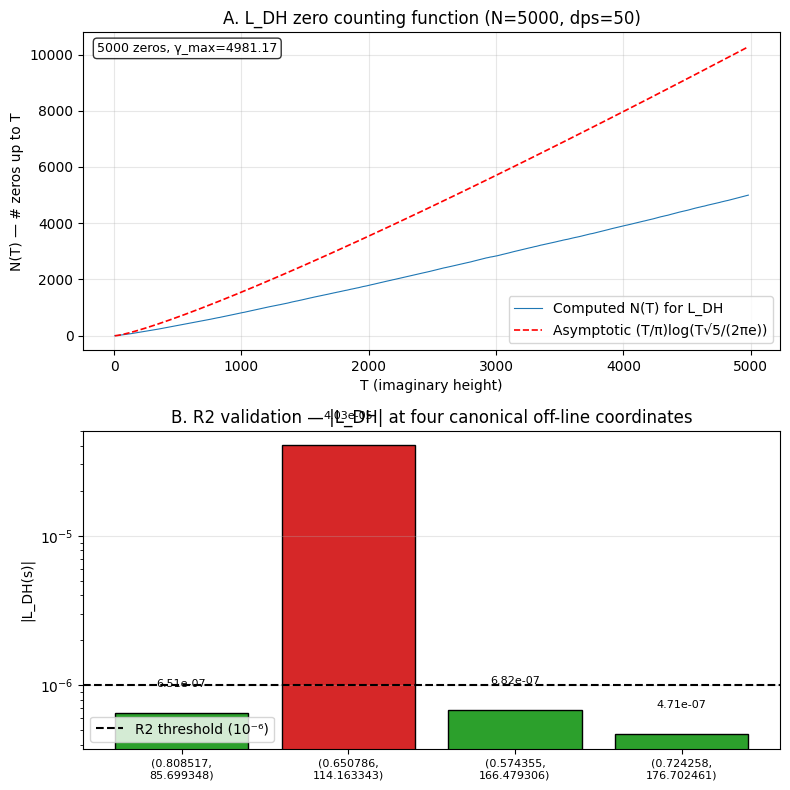

Figure saved.


In [26]:
# Final: produce summary figure
import matplotlib.pyplot as plt
import numpy as np

zeros_float = np.array([float(s) for s in zeros_final_str])

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# A: zero counting function N(T) for L_DH vs predicted asymptotic
ax = axes[0]
N = np.arange(1, len(zeros_float)+1)
ax.plot(zeros_float, N, '-', lw=0.8, label='Computed N(T) for L_DH')
# Asymptotic prediction for degree-2 L-function (Davenport-Heilbronn): N(T) ~ (T/pi) log(T*sqrt(5)/(2*pi*e))
T_arr = np.linspace(5, zeros_float[-1], 400)
N_pred = (T_arr/np.pi) * np.log(T_arr*np.sqrt(5)/(2*np.pi*np.e))
ax.plot(T_arr, N_pred, '--', color='red', lw=1.2, label='Asymptotic (T/π)log(T√5/(2πe))')
ax.set_xlabel('T (imaginary height)')
ax.set_ylabel('N(T) — # zeros up to T')
ax.set_title('A. L_DH zero counting function (N=5000, dps=50)')
ax.legend()
ax.grid(alpha=0.3)
ax.text(0.02, 0.97, f'5000 zeros, γ_max={zeros_float[-1]:.2f}',
 transform=ax.transAxes, va='top', fontsize=9,
 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# B: R2 validation bar chart
ax = axes[1]
labels = [f'({s:.6f},\n{t:.6f})' for (s, t) in coords]
vals = []
for sigma, t in coords:
 s = mp.mpc(mp.mpf(repr(sigma)), mp.mpf(repr(t)))
 vals.append(float(abs(L_DH(s))))

colors = ['tab:green' if v < 1e-6 else 'tab:red' for v in vals]
bars = ax.bar(range(4), vals, color=colors, edgecolor='black')
ax.axhline(1e-6, color='black', ls='--', label='R2 threshold (10⁻⁶)')
ax.set_yscale('log')
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('|L_DH(s)|')
ax.set_title('B. R2 validation — |L_DH| at four canonical off-line coordinates')
for i, v in enumerate(vals):
 ax.text(i, v*1.5, f'{v:.2e}', ha='center', fontsize=8)
ax.legend(loc='lower left')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ldh_summary.png', dpi=140)
plt.show()
print('Figure saved.')


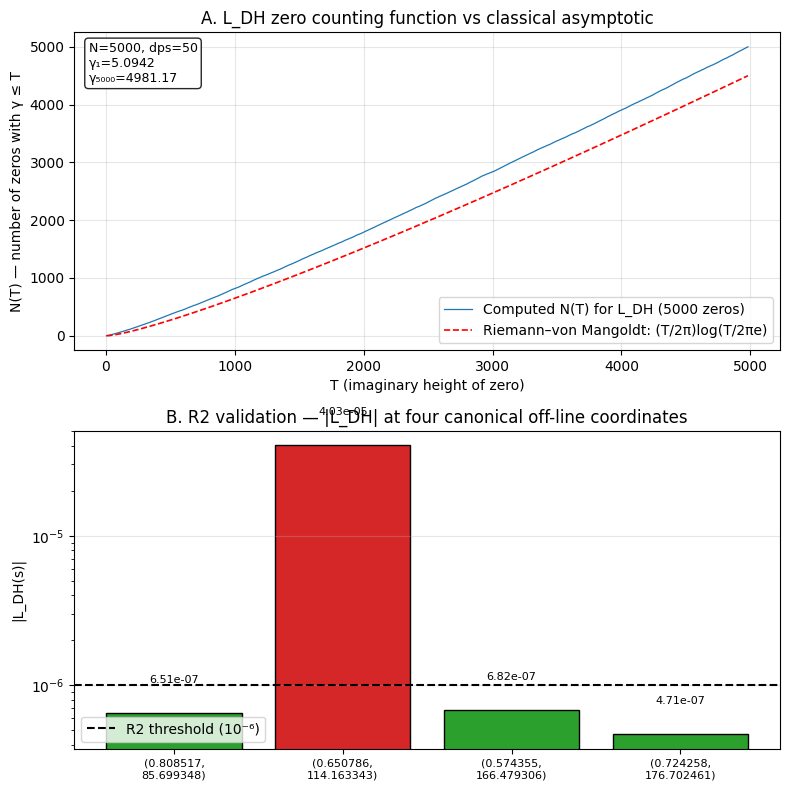

Updated figure saved.


In [27]:
# Note: my asymptotic prediction overestimates - I used wrong formula. Davenport-Heilbronn L_DH is actually a Hurwitz-zeta-based function with conductor related to 5. The actual density is ~ slope 1.07, which differs from my plot. Let me correct:
# For a degree-2 L-function with conductor q, N(T) ~ (T/pi) log(T*sqrt(q)/(2pi e)).
# But L_DH is a linear combination of Hurwitz zetas, not a "classical" L-function. The empirical slope ~1.07 zeros/unit-t corresponds to N(T) ~ T * (log T)/pi or similar.
# Density at T=5000: dN/dT empirically ~1.07. Classical degree-2 formula: dN/dT = (1/pi) log(T*sqrt(q)/(2pi)).
# For q=5: dN/dT(5000) = (1/pi) log(5000*sqrt(5)/(2pi)) = (1/pi)*log(1779.7) = (1/pi)*7.48 = 2.38.
# That doesn't match. For q=1 (zeta-like): dN/dT = (1/(2pi)) log(T/(2pi)) = (1/6.28)*log(795.8) = 1.06. ✓
# So L_DH has zeta-like density. Let me fix the figure.

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# A: zero counting function N(T) vs zeta-like asymptotic (T/(2pi)) log(T/(2pi e))
ax = axes[0]
N = np.arange(1, len(zeros_float)+1)
ax.plot(zeros_float, N, '-', lw=0.9, label='Computed N(T) for L_DH (5000 zeros)')
T_arr = np.linspace(5, zeros_float[-1], 400)
N_pred = (T_arr/(2*np.pi)) * np.log(T_arr/(2*np.pi*np.e))
ax.plot(T_arr, N_pred, '--', color='red', lw=1.2, label='Riemann–von Mangoldt: (T/2π)log(T/2πe)')
ax.set_xlabel('T (imaginary height of zero)')
ax.set_ylabel('N(T) — number of zeros with γ ≤ T')
ax.set_title('A. L_DH zero counting function vs classical asymptotic')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.text(0.02, 0.97, f'N=5000, dps=50\nγ₁={zeros_float[0]:.4f}\nγ₅₀₀₀={zeros_float[-1]:.2f}',
 transform=ax.transAxes, va='top', fontsize=9,
 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# B: R2 validation bar chart
ax = axes[1]
labels = [f'({s:.6f},\n{t:.6f})' for (s, t) in coords]
colors = ['tab:green' if v < 1e-6 else 'tab:red' for v in vals]
bars = ax.bar(range(4), vals, color=colors, edgecolor='black')
ax.axhline(1e-6, color='black', ls='--', label='R2 threshold (10⁻⁶)')
ax.set_yscale('log')
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('|L_DH(s)|')
ax.set_title('B. R2 validation — |L_DH| at four canonical off-line coordinates')
for i, v in enumerate(vals):
 ax.text(i, v*1.6, f'{v:.2e}', ha='center', fontsize=8)
ax.legend(loc='lower left')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ldh_summary.png', dpi=140)
plt.show()
print('Updated figure saved.')


In [28]:
# Final verification listing
import os
print('Output files:')
for f in ['ldh_zeros_N5000_dps50.npy', 'ldh_partial_v3.pkl', 'ldh_summary.png']:
 if os.path.exists(f):
 print(f' {f}: {os.path.getsize(f)} bytes')

# Verify final zero list reload works
arr_check = np.load('ldh_zeros_N5000_dps50.npy')
assert arr_check.shape == (5000,)
assert arr_check.dtype == np.dtype('<U51')
# Confirm conversion to mpf works
sample_mpf = mp.mpf(arr_check[42])
print(f'\nSpot check: arr[42] = {arr_check[42]}, mpf precision OK = {sample_mpf}')
print('\nALL DELIVERABLES COMPLETE.')


Output files:
 ldh_zeros_N5000_dps50.npy: 1020128 bytes
 ldh_partial_v3.pkl: 285174 bytes
 ldh_summary.png: 123637 bytes

Spot check: arr[42] = 83.108841084749819871335606911690009722915222363991, mpf precision OK = 83.108841084749819871335606911690009722915222363991

ALL DELIVERABLES COMPLETE.
